## 10. Taller

Implemente Minimax para **Tres en raya (Tic-Tac-Toe)**.

Puede representar el tablero como una tupla de nueve posiciones:

```python
(
    "X", "O", " ",
    " ", "X", " ",
    "O", " ", " "
)
```

Suponga:

- `X` es MAX;
- `O` es MIN;
- victoria de `X`: `+1`;
- empate: `0`;
- victoria de `O`: `-1`.

Implemente como mínimo:

```python
acciones(tablero)
resultado(tablero, accion, jugador)
terminal(tablero)
utilidad(tablero)
minimax_tictactoe(tablero, es_max)
```

In [7]:
# Implemente aquí Minimax para Tres en raya.

def acciones(tablero):
    jugadas = []

    for posiciones in range(len(tablero)):
        if tablero[posiciones] == " ":
            jugadas.append(posiciones)

    return jugadas

def resultado(tablero, accion, jugador):
    tablero_aux = list(tablero)
    tablero_aux[accion] = jugador
    return tuple(tablero_aux)

def terminal(tablero):
    combinaciones = [
        (0, 1, 2),
        (3, 4, 5),
        (6, 7, 8),
        (0, 3, 6),
        (1, 4, 7),
        (2, 5, 8),
        (0, 4, 8),
        (2, 4, 6)
    ]

    for combinacion in combinaciones:
        a, b, c = combinacion

        if tablero[a] == tablero[b] == tablero[c] and tablero[a] != " ":
            return True

    if " " not in tablero:
        return True

    return False

def utilidad(tablero):
    combinaciones = [
        (0, 1, 2),
        (3, 4, 5),
        (6, 7, 8),
        (0, 3, 6),
        (1, 4, 7),
        (2, 5, 8),
        (0, 4, 8),
        (2, 4, 6)
    ]

    for combinacion in combinaciones:
        a, b, c = combinacion

        if tablero[a] == tablero[b] == tablero[c] and tablero[a] != " ":

            if tablero[a] == "X":
                return 1
            else:
                return -1

    return 0
    

def minimax_tictactoe(tablero, es_max):

    if terminal(tablero):
        return utilidad(tablero)

    valores = []

    for accion in acciones(tablero):

        if es_max:
            nuevo_tablero = resultado(tablero, accion, "X")
        else:
            nuevo_tablero = resultado(tablero, accion, "O")

        valor = minimax_tictactoe(
            nuevo_tablero,
            not es_max
        )

        valores.append(valor)

    if es_max:
        return max(valores)

    else:
        return min(valores)

def mejor_jugada(tablero):
    opciones = []

    for accion in acciones(tablero):
        nuevo_tablero = resultado(tablero, accion, "X")

        valor = minimax_tictactoe(
            nuevo_tablero,
            False
        )

        opciones.append((valor, accion))

    mejor_valor, mejor_accion = max(
    opciones,
    key=lambda x: x[0]
    )

    return mejor_valor, mejor_accion, opciones

In [10]:
tablero_prueba = (
    "X", " ", "X",
    "O", "X", " ",
    "O", " ", "O"
)

print("Acciones:", acciones(tablero_prueba))
print("Terminal:", terminal(tablero_prueba))
print("Valor Minimax:", minimax_tictactoe(tablero_prueba, True))

valor, jugada, opciones = mejor_jugada(tablero_prueba)

print("Evaluación de las jugadas:", opciones)
print("Mejor jugada para MAX:", jugada)
print("Valor de la mejor jugada:", valor)

Acciones: [1, 5, 7]
Terminal: False
Valor Minimax: 1
Evaluación de las jugadas: [(1, 1), (-1, 5), (0, 7)]
Mejor jugada para MAX: 1
Valor de la mejor jugada: 1


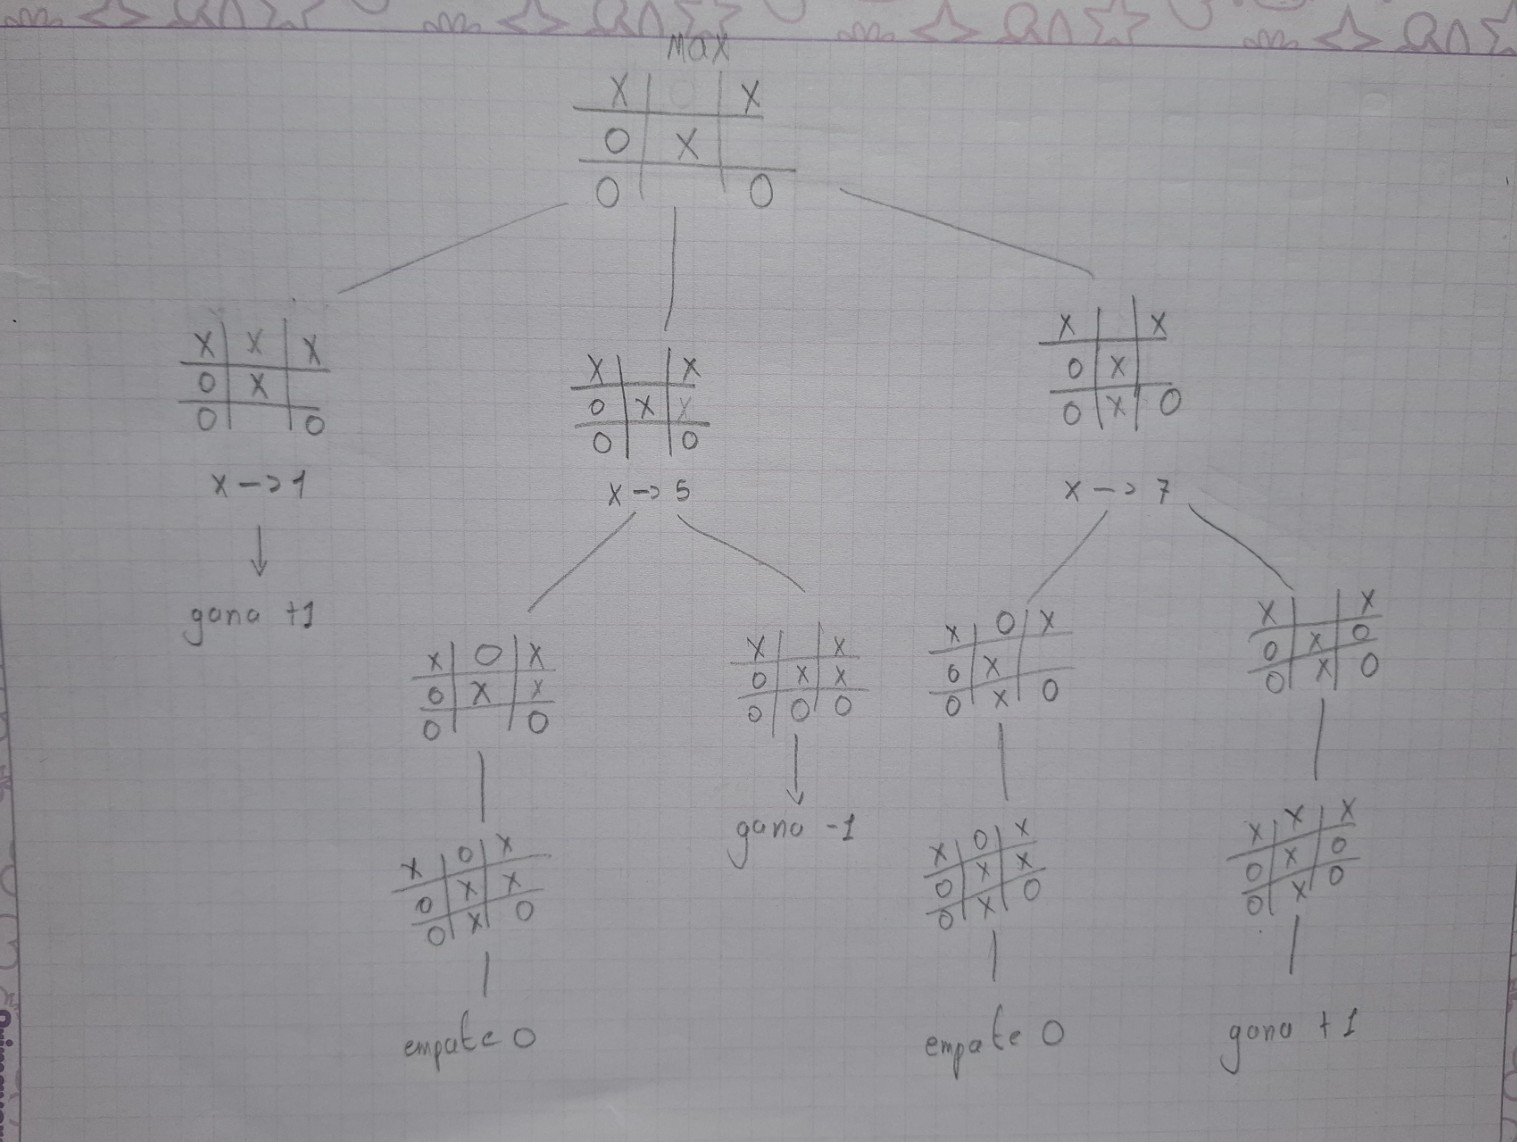

### Para el juego de las piedras
Modifique las reglas para permitir retirar únicamente `1`, `2` o `4` piedras.

Analice:

- posiciones ganadoras;
- posiciones perdedoras;
- mejor movimiento para MAX.


### Pregunta final

**¿Por qué una decisión que parece buena de manera inmediata puede ser mala después de considerar la respuesta del adversario?**

In [11]:
MOVIMIENTOS = (1, 2, 4)


def movimientos_validos(piedras):
    movimientos = []

    for movimiento in MOVIMIENTOS:
        if movimiento <= piedras:
            movimientos.append(movimiento)

    return movimientos

In [ ]:
def minimax_piedras(piedras, es_max):

    if piedras == 0:
        if es_max:
            return -1
        else:
            return 1

    valores = []

    for movimiento in movimientos_validos(piedras):

        nuevas_piedras = piedras - movimiento

        valor = minimax_piedras(
            nuevas_piedras,
            not es_max
        )

        valores.append(valor)

    if es_max:
        return max(valores)
    else:
        return min(valores)

def mejor_jugada_piedras(piedras):
    opciones = []

    for movimiento in movimientos_validos(piedras):

        nuevas_piedras = piedras - movimiento

        valor = minimax_piedras(
            nuevas_piedras,
            False
        )

        opciones.append((valor, movimiento))

    mejor_valor, mejor_movimiento = max(
        opciones,
        key=lambda x: x[0]
    )

    return mejor_valor, mejor_movimiento, opciones


In [15]:
piedras = 10

print("Cantidad de piedras:", piedras)
print("Movimientos posibles:", movimientos_validos(piedras))
print("Valor Minimax:", minimax_piedras(piedras, True))

valor, movimiento, opciones = mejor_jugada_piedras(piedras)

print("Evaluación de movimientos:", opciones)
print("Mejor movimiento para MAX:", movimiento)
print("Valor:", valor)
print("Análisis de posiciones:")

for piedras in range(1, 16):
    valor = minimax_piedras(piedras, True)

    if valor == 1:
        print(piedras, "piedras -> Posición ganadora para MAX")
    else:
        print(piedras, "piedras -> Posición perdedora para MAX")

Cantidad de piedras: 10
Movimientos posibles: [1, 2, 4]
Valor Minimax: 1
Evaluación de movimientos: [(1, 1), (-1, 2), (1, 4)]
Mejor movimiento para MAX: 1
Valor: 1
Análisis de posiciones:
1 piedras -> Posición ganadora para MAX
2 piedras -> Posición ganadora para MAX
3 piedras -> Posición perdedora para MAX
4 piedras -> Posición ganadora para MAX
5 piedras -> Posición ganadora para MAX
6 piedras -> Posición perdedora para MAX
7 piedras -> Posición ganadora para MAX
8 piedras -> Posición ganadora para MAX
9 piedras -> Posición perdedora para MAX
10 piedras -> Posición ganadora para MAX
11 piedras -> Posición ganadora para MAX
12 piedras -> Posición perdedora para MAX
13 piedras -> Posición ganadora para MAX
14 piedras -> Posición ganadora para MAX
15 piedras -> Posición perdedora para MAX


# Análisis realizado:
Al modificar los movimientos permitidos a 1, 2 o 4 piedras, se observa que las posiciones perdedoras para MAX son 3, 6, 9, 12 y 15. Por lo tanto, las posiciones que son múltiplos de 3 son perdedoras, mientras que las demás son ganadoras.
La estrategia consiste en realizar un movimiento que deje al adversario una cantidad de piedras múltiplo de 3.
Para una posición inicial de 10 piedras, Minimax evalúa retirar 1, 2 y 4 piedras con valores +1, -1 y +1, respectivamente. Por lo tanto, MAX puede retirar 1 o 4 piedras para mantener una estrategia ganadora. El programa selecciona 1 porque es el primer movimiento con el valor máximo encontrado.

# Pregunta final.

Podría decirse que una decisión parece buena porque inicialmente solo vemos nuestros propios escenarios y pensamos en las formas en las que podemos ganar. Evaluamos las posibilidades teniendo en cuenta cómo cada jugada nos beneficia o nos afecta. Sin embargo, cuando el oponente realiza su movimiento, el escenario puede cambiar completamente y una decisión que parecía buena puede terminar siendo perjudicial. Por eso no basta con pensar únicamente en nuestra siguiente jugada, sino que también debemos considerar las posibles respuestas del adversario y cómo reaccionaríamos ante ellas. Precisamente esto es lo que hace Minimax: analiza diferentes escenarios futuros teniendo en cuenta tanto nuestras decisiones como las del oponente, permitiendo elegir una jugada que siga siendo conveniente incluso después de considerar su respuesta.